# Verify MAT vs H5 Spectrogram and Prediction Consistency

Goal: ensure the on-the-fly MAT -> spectrogram -> model path matches the H5 stored spectrogram -> model path.

What we'll check:
- Same spectrogram values (after load, after normalization, and after resize)
- Same model inputs (tensor shapes/order)
- Same predictions (argmax and full probabilities)


In [37]:
# Imports and setup
import sys, os, pickle
from pathlib import Path
import numpy as np
import torch
import h5py
import scipy.io as sio
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

repo_root = Path.cwd().parent
if str(repo_root) not in sys.path:
    sys.path.append(str(repo_root))

from src.ssamba.utilities.training_utils import create_model
from src.ssamba.dataset import ONCSpectrogramDataset
from src.ssamba.utilities.spectrogram_utils import (
    load_mat_spectrogram,
    normalize_spectrogram,
    preprocess_to_tensor,
    preprocess_to_tensor_ctf,
    preprocess_with_resize_ctf,
    resize_to_target,
)
from src.ssamba.utilities.inference_utils import build_mat_dataloader

print('Python:', sys.version)
print('CUDA:', torch.cuda.is_available())


Python: 3.10.12 (main, Jan 17 2025, 14:35:34) [GCC 11.4.0]
CUDA: True


In [25]:
# Paths and config
DATA_H5 = "/home/sbialek/ONC/selfsupervision_anomalies_onc/data/different_locations_incl_backgroundpipelinenormals_multilabel.h5"
MODEL_DIR = Path("/home/sbialek/ONC/selfsupervision_anomalies_onc/data/trained-model/finetune/amba-base-f16-t16-b16-lr1e-4-m300-custom-tr0.8-fir_experiment_multiclass_avgtok2")
CHECKPOINT_PATH = MODEL_DIR / "models/ft-avgtok_best_checkpoint.pth"

# Optional: folder where the raw .mat files live (to match to H5 entries)
MAT_ROOTS = [
    "/mnt/z/CIOOS_Anomaly_detection_work/CambridgeBay/matfiles/",
]

TARGET_SIZE = (512, 512)
EXPECTED_SHAPE = (854, 1000)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)


Device: cuda


In [26]:
# Load model and recover label mapping from dataset args/H5
with open(MODEL_DIR / 'args.pkl', 'rb') as f:
    args = pickle.load(f)
args.multiclass = True
args.exp_dir = MODEL_DIR

model = create_model(args).to(DEVICE)
ckpt = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
state_dict = ckpt['model_state_dict'] if 'model_state_dict' in ckpt else ckpt
model.load_state_dict(state_dict)
model.eval()

# Build small dataset to recover class names
probe_ds = ONCSpectrogramDataset(
    data_path=DATA_H5,
    split='test',
    train_ratio=getattr(args, 'train_ratio', 0.8),
    val_ratio=getattr(args, 'val_ratio', 0.1),
    seed=getattr(args, 'split_seed', 42),
    target_length=getattr(args, 'target_length', 1024),
    num_mel_bins=getattr(args, 'num_mel_bins', 128),
    supervised=True,
    subsample_test=False,
    multiclass=True,
    num_classes=getattr(args, 'num_classes', 8),
)
_ = probe_ds[0]
class_names = [probe_ds.index_to_label[i] for i in range(len(probe_ds.index_to_label))]
print('Classes:', class_names)


Vision Mamba Config: {'img_size': (512, 512), 'patch_size': 16, 'stride': 16, 'embed_dim': 768, 'depth': 24, 'channels': 1, 'num_classes': 8, 'drop_rate': 0.0, 'drop_path_rate': 0.1, 'norm_epsilon': 1e-05, 'rms_norm': False, 'residual_in_fp32': False, 'fused_add_norm': False, 'if_rope': False, 'if_rope_residual': False, 'bimamba_type': 'v2', 'if_cls_token': True, 'if_devide_out': True, 'use_double_cls_token': False, 'use_middle_cls_token': False, 'if_bidirectional': True, 'final_pool_type': 'none', 'if_abs_pos_embed': True, 'if_bimamba': False}
Loading pretrained model from: /scratch/merileo/exp/pretrain/amba-base-f16-t16-b16-lr1e-4-m300-custom-tr0.8-full_dataset_hydrophones_FINAL/models/pretrain-joint_best_checkpoint.pth
Loaded state dict keys: dict_keys(['epoch', 'global_step', 'model_state_dict', 'optimizer_state_dict', 'scheduler_state_dict', 'best_metrics', 'val_acc', 'args'])
Now loading SSL pretrained model from /scratch/merileo/exp/pretrain/amba-base-f16-t16-b16-lr1e-4-m300-cus

In [27]:
# Utilities to map H5 entries to MAT files
from glob import glob

def find_matching_mat(source_name: str, roots):
    """Return full path to a .mat file whose basename starts with source_name."""
    for r in roots:
        cand = glob(os.path.join(r, f"**/{source_name}*.mat"), recursive=True)
        if cand:
            return cand[0]
    return None

# Quick sanity: open H5 and get a few sample indices and their source names
with h5py.File(DATA_H5, 'r') as hf:
    N = len(hf['spectrograms'])
    sources = hf['sources'][:]

# Decode bytes
sources = [s.decode('utf-8') if isinstance(s, (bytes, np.bytes_)) else str(s) for s in sources]
print('Total H5 samples:', len(sources))

# Choose a subset to compare
sample_indices = list(range(0, min(50, len(sources))))
print('Comparing first', len(sample_indices), 'samples')


Total H5 samples: 16500
Comparing first 50 samples


In [29]:
# Diagnose H5<->MAT matching
from glob import glob
from collections import Counter

print('MAT_ROOTS:', MAT_ROOTS)

# Gather MAT files
mat_paths = []
for r in MAT_ROOTS:
    if os.path.isdir(r):
        mat_paths.extend(glob(os.path.join(r, '**', '*.mat'), recursive=True))
    else:
        print('Warning: MAT root does not exist:', r)
mat_paths = sorted(set(mat_paths))
print('Total .mat files found under MAT_ROOTS:', len(mat_paths))

# Normalize helpers
def norm_name(x):
    try:
        return Path(x).name.strip().lower()
    except Exception:
        return str(x).strip().lower()

def norm_stem(x):
    try:
        return Path(x).stem.strip().lower()
    except Exception:
        return str(x).strip().lower().rsplit('.', 1)[0]

# H5 sources
h5_names = [norm_name(s) for s in sources]
h5_stems = [norm_stem(s) for s in sources]
print('H5 .mat-like entries:', sum(1 for n in h5_names if n.endswith('.mat')))
print('Example H5 sources:', h5_names[:5])

# MAT filenames
mat_names = [norm_name(p) for p in mat_paths]
mat_stems = [norm_stem(p) for p in mat_paths]

# Intersections
common_names = set(h5_names) & set(mat_names)
common_stems = set(h5_stems) & set(mat_stems)
print('Exact filename matches:', len(common_names))
print('Stem matches:', len(common_stems))

# Show a few non-matching examples with best-guess candidates
if len(common_stems) == 0:
    print('\nNo stem matches. Showing a few H5 stems and similar MAT stems:')
    import difflib
    for s in h5_stems[:10]:
        # candidates: prefix/suffix or close match
        pref = [m for m in mat_stems if m.startswith(s) or s.startswith(m)]
        if not pref:
            close = difflib.get_close_matches(s, mat_stems, n=3, cutoff=0.6)
        else:
            close = pref[:3]
        print(f"  H5: {s} -> candidates: {close}")

# Also check hydrophone prefixes
def get_hydro_prefix(n):
    # e.g., ICLISTENHF1951 from 'ICLISTENHF1951_2018...mat'
    base = Path(n).stem
    return base.split('_')[0] if '_' in base else base

h5_prefixes = Counter(get_hydro_prefix(n) for n in h5_names)
mat_prefixes = Counter(get_hydro_prefix(n) for n in mat_names)
print('\nTop H5 prefixes:', h5_prefixes.most_common(5))
print('Top MAT prefixes:', mat_prefixes.most_common(5))

# If zero MAT files found, hint to update MAT_ROOTS
if len(mat_paths) == 0:
    print('\nNo .mat files found. Update MAT_ROOTS to point to your raw MAT directory/directories.')


MAT_ROOTS: ['/mnt/z/CIOOS_Anomaly_detection_work/CambridgeBay/matfiles/']
Total .mat files found under MAT_ROOTS: 1000
H5 .mat-like entries: 16500
Example H5 sources: ['iclistenhf1951_20240902t173038.996z_20240902t173538.996z-spect_plotres.mat', 'iclistenhf1951_20240902t173447.989z_20240902t173947.989z-spect_plotres.mat', 'iclistenhf1951_20240902t173947.989z_20240902t174447.989z-spect_plotres.mat', 'iclistenhf1951_20240902t174535.989z_20240902t175035.989z-spect_plotres.mat', 'iclistenhf1951_20240902t175035.989z_20240902t175535.989z-spect_plotres.mat']
Exact filename matches: 1000
Stem matches: 1000

Top H5 prefixes: [('iclistenhf1354', 4379), ('iclistenhf1253', 3113), ('iclistenhf1266', 2279), ('iclistenhf6324', 1578), ('iclistenhf1951', 1000)]
Top MAT prefixes: [('iclistenhf1951', 1000)]


In [30]:
# Build case-insensitive MAT index and compute matched H5 indices
from collections import defaultdict

# Build indices
mat_by_name = {}
mat_by_stem = {}
for p in mat_paths:
    n = norm_name(p)
    s = norm_stem(p)
    if n not in mat_by_name:
        mat_by_name[n] = p
    if s not in mat_by_stem:
        mat_by_stem[s] = p

# Helper: case-insensitive resolver
def find_matching_mat_ci(source_name: str):
    n = norm_name(source_name)
    s = norm_stem(source_name)
    if n in mat_by_name:
        return mat_by_name[n]
    if s in mat_by_stem:
        return mat_by_stem[s]
    # also try prefix-based stem match (common pattern with extra suffixes)
    for cand_stem, path in mat_by_stem.items():
        if cand_stem.startswith(s) or s.startswith(cand_stem):
            return path
    return None

# Compute matched indices across whole H5
matched_indices = []
for i, src in enumerate(sources):
    if find_matching_mat_ci(src) is not None:
        matched_indices.append(i)

print('Total H5 entries:', len(sources))
print('Total matched (by name/stem):', len(matched_indices))
if matched_indices:
    # Set the comparison subset to matched items
    sample_indices = matched_indices[:min(50, len(matched_indices))]
    print('Using matched sample_indices of length:', len(sample_indices))
    # Show a couple example mappings
    ex = matched_indices[:5]
    for i in ex:
        print('H5 -> MAT:', sources[i], '->', find_matching_mat_ci(sources[i]))
else:
    print('No matches found. Likely MAT_ROOTS does not include these hydrophones; update MAT_ROOTS.')


Total H5 entries: 16500
Total matched (by name/stem): 1000
Using matched sample_indices of length: 50
H5 -> MAT: ICLISTENHF1951_20240902T173038.996Z_20240902T173538.996Z-spect_plotRes.mat -> /mnt/z/CIOOS_Anomaly_detection_work/CambridgeBay/matfiles/ICLISTENHF1951_20240902T173038.996Z_20240902T173538.996Z-spect_plotRes.mat
H5 -> MAT: ICLISTENHF1951_20240902T173447.989Z_20240902T173947.989Z-spect_plotRes.mat -> /mnt/z/CIOOS_Anomaly_detection_work/CambridgeBay/matfiles/ICLISTENHF1951_20240902T173447.989Z_20240902T173947.989Z-spect_plotRes.mat
H5 -> MAT: ICLISTENHF1951_20240902T173947.989Z_20240902T174447.989Z-spect_plotRes.mat -> /mnt/z/CIOOS_Anomaly_detection_work/CambridgeBay/matfiles/ICLISTENHF1951_20240902T173947.989Z_20240902T174447.989Z-spect_plotRes.mat
H5 -> MAT: ICLISTENHF1951_20240902T174535.989Z_20240902T175035.989Z-spect_plotRes.mat -> /mnt/z/CIOOS_Anomaly_detection_work/CambridgeBay/matfiles/ICLISTENHF1951_20240902T174535.989Z_20240902T175035.989Z-spect_plotRes.mat
H5 -> MAT:

In [31]:
# Core comparison loop (case-insensitive matching + matched indices)
results = []

# Prefer matched_indices computed earlier if available
indices_to_check = sample_indices
if 'matched_indices' in globals() and len(matched_indices) > 0:
    indices_to_check = matched_indices[:min(50, len(matched_indices))]

print(f"Comparing arrays for {len(indices_to_check)} samples...")
with h5py.File(DATA_H5, 'r') as hf:
    for idx in tqdm(indices_to_check, desc='array-compare'):
        src = sources[idx]
        h5_arr = hf['spectrograms'][idx]  # [F, T, 1]
        h5_arr_ft = h5_arr[..., 0].astype(np.float32)

        # Use case-insensitive lookup built earlier
        mat_path = find_matching_mat_ci(src)
        if mat_path is None:
            results.append({'index': idx, 'source': src, 'status': 'no_mat'})
            continue

        # Load MAT raw spectrogram [F, T]
        mat_raw = load_mat_spectrogram(mat_path, EXPECTED_SHAPE)

        # Align pipelines: H5 does resize -> normalize; do the same for MAT before comparing
        h5_F, h5_T = h5_arr_ft.shape
        mat_raw_h5 = resize_to_target(mat_raw, (h5_F, h5_T))
        h5_raw = h5_arr_ft

        # Normalize both using the same function as inference (after resize)
        mat_norm_h5 = normalize_spectrogram(
            mat_raw_h5,
            dataset_mean=getattr(args, 'dataset_mean', None),
            dataset_std=getattr(args, 'dataset_std', None),
            amount=1.0 if getattr(args, 'amount', None) is None else getattr(args, 'amount')
        )
        h5_norm = normalize_spectrogram(
            h5_raw,
            dataset_mean=getattr(args, 'dataset_mean', None),
            dataset_std=getattr(args, 'dataset_std', None),
            amount=1.0 if getattr(args, 'amount', None) is None else getattr(args, 'amount')
        )

        # Prepare inputs at TARGET_SIZE without unnecessary extra resampling
        mat_to_target = mat_norm_h5 if mat_norm_h5.shape == TARGET_SIZE else resize_to_target(mat_norm_h5, TARGET_SIZE)
        h5_to_target = h5_norm if h5_norm.shape == TARGET_SIZE else resize_to_target(h5_norm, TARGET_SIZE)

        # Compute diffs
        def stats(a, b):
            diff = a - b
            return dict(
                mae=float(np.mean(np.abs(diff))),
                max=float(np.max(np.abs(diff))),
                mse=float(np.mean(diff**2)),
                corr=float(np.corrcoef(a.flatten(), b.flatten())[0, 1]) if a.size and b.size else float('nan'),
            )

        # Raw (post-resize) comparison
        raw_stats = stats(mat_raw_h5, h5_raw)
        # Normalized at H5 size
        norm_stats = stats(mat_norm_h5, h5_norm)
        # Final model input size
        resized_stats = stats(mat_to_target, h5_to_target)

        results.append({
            'index': idx,
            'source': src,
            'status': 'ok',
            'mat_path': mat_path,
            **{f'raw_{k}': v for k, v in raw_stats.items()},
            **{f'norm_{k}': v for k, v in norm_stats.items()},
            **{f'resize_{k}': v for k, v in resized_stats.items()},
        })

# Show a quick summary + a couple of mappings for sanity
import pandas as pd
res_df = pd.DataFrame(results)
print('Matched:', (res_df['status'] == 'ok').sum(), '/', len(res_df))
for _, r in res_df.head(3).iterrows():
    if r['status'] == 'ok':
        print('OK mapping:', r['source'], '->', r['mat_path'])
res_df.head(10)


Comparing arrays for 50 samples...


array-compare:   0%|          | 0/50 [00:00<?, ?it/s]

Matched: 50 / 50
OK mapping: ICLISTENHF1951_20240902T173038.996Z_20240902T173538.996Z-spect_plotRes.mat -> /mnt/z/CIOOS_Anomaly_detection_work/CambridgeBay/matfiles/ICLISTENHF1951_20240902T173038.996Z_20240902T173538.996Z-spect_plotRes.mat
OK mapping: ICLISTENHF1951_20240902T173447.989Z_20240902T173947.989Z-spect_plotRes.mat -> /mnt/z/CIOOS_Anomaly_detection_work/CambridgeBay/matfiles/ICLISTENHF1951_20240902T173447.989Z_20240902T173947.989Z-spect_plotRes.mat
OK mapping: ICLISTENHF1951_20240902T173947.989Z_20240902T174447.989Z-spect_plotRes.mat -> /mnt/z/CIOOS_Anomaly_detection_work/CambridgeBay/matfiles/ICLISTENHF1951_20240902T173947.989Z_20240902T174447.989Z-spect_plotRes.mat


,index,source,status,mat_path,raw_mae,raw_max,raw_mse,raw_corr,norm_mae,norm_max,norm_mse,norm_corr,resize_mae,resize_max,resize_mse,resize_corr
0,0,ICLISTENHF1951_20240902T173038.996Z_20240902T1...,ok,/mnt/z/CIOOS_Anomaly_detection_work/CambridgeB...,9.197432e-07,0.000008,4.665865e-12,1.0,3.370764e-08,7.152557e-07,6.449749e-15,1.0,3.370764e-08,7.152557e-07,6.449749e-15,1.0
1,1,ICLISTENHF1951_20240902T173447.989Z_20240902T1...,ok,/mnt/z/CIOOS_Anomaly_detection_work/CambridgeB...,1.233143e-06,0.000008,7.368524e-12,1.0,4.526110e-08,7.152557e-07,1.019928e-14,1.0,4.526110e-08,7.152557e-07,1.019928e-14,1.0
2,2,ICLISTENHF1951_20240902T173947.989Z_20240902T1...,ok,/mnt/z/CIOOS_Anomaly_detection_work/CambridgeB...,1.121657e-06,0.000008,6.273617e-12,1.0,4.110098e-08,7.152557e-07,8.690315e-15,1.0,4.110098e-08,7.152557e-07,8.690315e-15,1.0
3,3,ICLISTENHF1951_20240902T174535.989Z_20240902T1...,ok,/mnt/z/CIOOS_Anomaly_detection_work/CambridgeB...,1.085503e-06,0.000008,5.796194e-12,1.0,3.978574e-08,7.152557e-07,8.007835e-15,1.0,3.978574e-08,7.152557e-07,8.007835e-15,1.0
4,4,ICLISTENHF1951_20240902T175035.989Z_20240902T1...,ok,/mnt/z/CIOOS_Anomaly_detection_work/CambridgeB...,1.073586e-06,0.000008,5.741663e-12,1.0,3.937514e-08,7.152557e-07,7.944218e-15,1.0,3.937514e-08,7.152557e-07,7.944218e-15,1.0
5,5,ICLISTENHF1951_20240902T175535.989Z_20240902T1...,ok,/mnt/z/CIOOS_Anomaly_detection_work/CambridgeB...,1.056156e-06,0.000008,5.533402e-12,1.0,3.867925e-08,7.152557e-07,7.641801e-15,1.0,3.867925e-08,7.152557e-07,7.641801e-15,1.0
6,6,ICLISTENHF1951_20240902T180035.989Z_20240902T1...,ok,/mnt/z/CIOOS_Anomaly_detection_work/CambridgeB...,7.623580e-07,0.000008,4.274999e-12,1.0,2.796499e-08,7.152557e-07,5.914028e-15,1.0,2.796499e-08,7.152557e-07,5.914028e-15,1.0
7,7,ICLISTENHF1951_20240902T180208.981Z_20240902T1...,ok,/mnt/z/CIOOS_Anomaly_detection_work/CambridgeB...,1.169200e-06,0.000008,6.707299e-12,1.0,4.282635e-08,7.152557e-07,9.264984e-15,1.0,4.282635e-08,7.152557e-07,9.264984e-15,1.0
8,8,ICLISTENHF1951_20240830T010510.000Z_20240830T0...,ok,/mnt/z/CIOOS_Anomaly_detection_work/CambridgeB...,9.975909e-07,0.000008,4.616477e-12,1.0,3.659474e-08,7.152557e-07,6.398638e-15,1.0,3.659474e-08,7.152557e-07,6.398638e-15,1.0
9,9,ICLISTENHF1951_20240830T011010.000Z_20240830T0...,ok,/mnt/z/CIOOS_Anomaly_detection_work/CambridgeB...,9.492774e-07,0.000008,4.116366e-12,1.0,3.485616e-08,7.152557e-07,5.709529e-15,1.0,3.485616e-08,7.152557e-07,5.709529e-15,1.0


In [11]:
print(sources[7000])
print(Path(src).stem)

ICLISTENHF6324_20240628T025500.000Z_20240628T030000.000Z-OD-spect_plotRes.mat
ICLISTENHF1951_20240830T042824.000Z_20240830T043324.000Z-spect_plotRes


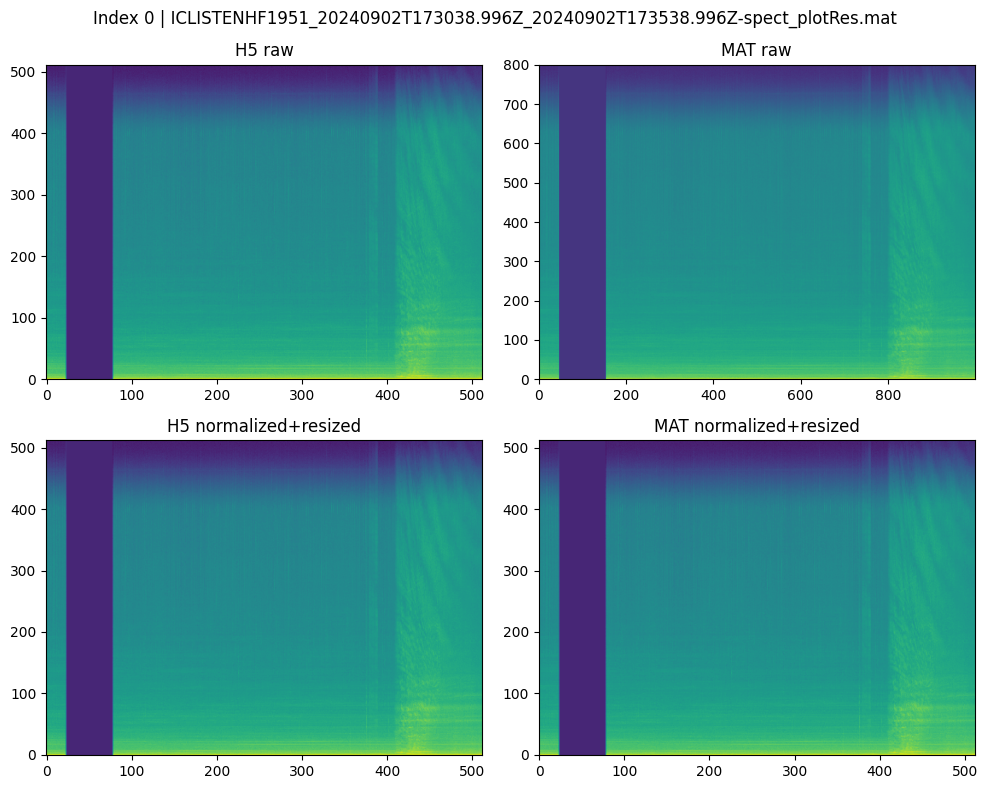

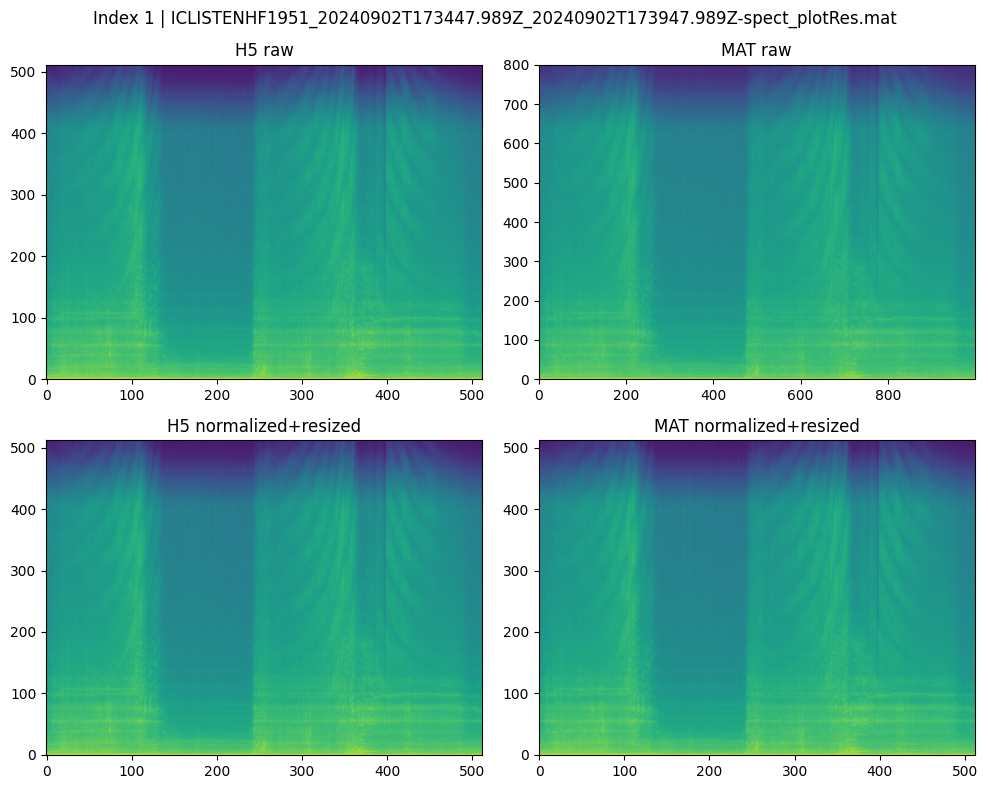

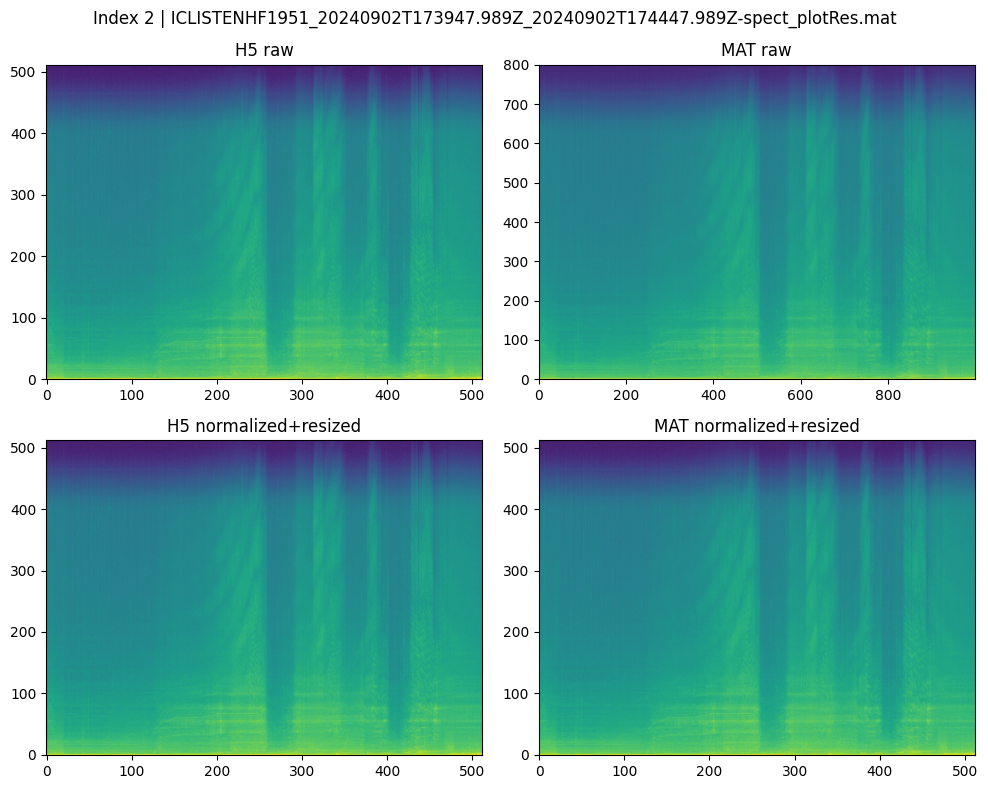

In [32]:
# Visual spot check for a couple samples
ok_rows = res_df[res_df['status'] == 'ok'].head(3)
for _, r in ok_rows.iterrows():
    idx = int(r['index'])
    src = r['source']
    with h5py.File(DATA_H5, 'r') as hf:
        h5_arr = hf['spectrograms'][idx][..., 0].astype(np.float32)
    mat_arr = load_mat_spectrogram(r['mat_path'], EXPECTED_SHAPE)

    h5_n = normalize_spectrogram(h5_arr, dataset_mean=getattr(args, 'dataset_mean', None), dataset_std=getattr(args, 'dataset_std', None), amount=1.0 if getattr(args, 'amount', None) is None else getattr(args, 'amount'))
    mat_n = normalize_spectrogram(mat_arr, dataset_mean=getattr(args, 'dataset_mean', None), dataset_std=getattr(args, 'dataset_std', None), amount=1.0 if getattr(args, 'amount', None) is None else getattr(args, 'amount'))

    h5_r = resize_to_target(h5_n, TARGET_SIZE)
    mat_r = resize_to_target(mat_n, TARGET_SIZE)

    fig, axs = plt.subplots(2, 2, figsize=(10, 8))
    fig.suptitle(f"Index {idx} | {src}")
    axs[0,0].imshow(h5_arr, origin='lower', aspect='auto'); axs[0,0].set_title('H5 raw')
    axs[0,1].imshow(mat_arr, origin='lower', aspect='auto'); axs[0,1].set_title('MAT raw')
    axs[1,0].imshow(h5_r, origin='lower', aspect='auto'); axs[1,0].set_title('H5 normalized+resized')
    axs[1,1].imshow(mat_r, origin='lower', aspect='auto'); axs[1,1].set_title('MAT normalized+resized')
    plt.tight_layout(); plt.show()


In [21]:
# Compare predictions (argmax and probabilities)
from torch.nn.functional import softmax

pred_rows = []
print('Running prediction comparisons...')
with torch.no_grad():
    it = res_df[res_df['status'] == 'ok'].itertuples(index=False)
    for r in tqdm(it, total=(res_df['status'] == 'ok').sum(), desc='predict-compare'):
        idx = int(r.index)
        with h5py.File(DATA_H5, 'r') as hf:
            h5_arr = hf['spectrograms'][idx][..., 0].astype(np.float32)
        mat_arr = load_mat_spectrogram(r.mat_path, EXPECTED_SHAPE)

        # Normalize + resize + to tensor [1, T, F]
        h5_tensor = preprocess_with_resize_ctf(
            normalize_spectrogram(h5_arr,
                                   dataset_mean=getattr(args, 'dataset_mean', None),
                                   dataset_std=getattr(args, 'dataset_std', None),
                                   amount=1.0 if getattr(args, 'amount', None) is None else getattr(args, 'amount')),
            TARGET_SIZE
        ).unsqueeze(0).to(DEVICE)

        mat_tensor = preprocess_with_resize_ctf(
            normalize_spectrogram(mat_arr,
                                   dataset_mean=getattr(args, 'dataset_mean', None),
                                   dataset_std=getattr(args, 'dataset_std', None),
                                   amount=1.0 if getattr(args, 'amount', None) is None else getattr(args, 'amount')),
            TARGET_SIZE
        ).unsqueeze(0).to(DEVICE)

        # Forward
        logits_h5 = model(h5_tensor, task=getattr(args, 'task', 'ft_cls'))
        logits_mat = model(mat_tensor, task=getattr(args, 'task', 'ft_cls'))
        probs_h5 = softmax(logits_h5, dim=1).cpu().numpy()[0]
        probs_mat = softmax(logits_mat, dim=1).cpu().numpy()[0]

        pred_rows.append({
            'index': idx,
            'pred_h5': int(np.argmax(probs_h5)),
            'pred_mat': int(np.argmax(probs_mat)),
            'agree': bool(np.argmax(probs_h5) == np.argmax(probs_mat)),
            'kl_div': float(np.sum(probs_mat * (np.log((probs_mat + 1e-12) / (probs_h5 + 1e-12))))),
            'l1': float(np.mean(np.abs(probs_h5 - probs_mat))),
            'l2': float(np.sqrt(np.mean((probs_h5 - probs_mat)**2))),
        })

pred_df = pd.DataFrame(pred_rows)
print('Prediction argmax agreement:', pred_df['agree'].mean(), f"({len(pred_df)} compared)")
pred_df.head(10)


Running prediction comparisons...


predict-compare:   0%|          | 0/50 [00:00<?, ?it/s]

Prediction argmax agreement: 1.0 (50 compared)


,index,pred_h5,pred_mat,agree,kl_div,l1,l2
0,6379,4,4,True,-1.291990e-07,1.875451e-07,2.293695e-07
1,6380,0,0,True,-6.208433e-08,1.234584e-07,1.826346e-07
2,6381,0,0,True,2.665678e-08,1.111184e-07,1.670914e-07
3,6382,0,0,True,1.402090e-07,1.981389e-07,2.778972e-07
4,6383,3,3,True,8.325311e-08,4.987305e-08,9.099399e-08
5,6384,3,3,True,6.686017e-08,5.364564e-08,8.692185e-08
6,6385,3,3,True,4.593704e-08,1.199187e-07,2.003062e-07
7,6386,0,0,True,5.415646e-08,1.404260e-07,2.223078e-07
8,6387,3,3,True,5.816836e-08,5.495895e-08,9.667857e-08
9,6388,0,0,True,-2.244213e-08,5.866241e-08,9.638425e-08


In [ ]:
# Summaries & save
out_dir = Path('verify_mat_vs_h5')
out_dir.mkdir(exist_ok=True, parents=True)

# Merge and save
summary_df = res_df.merge(pred_df, on='index', how='left')
summary_path = out_dir / 'comparison_summary.csv'
summary_df.to_csv(summary_path, index=False)
print('Saved:', summary_path)

# Aggregate stats
ok_mask = summary_df['status'] == 'ok'
if ok_mask.any():
    print('\nArray diffs (median over matched):')
    for prefix in ['raw', 'norm', 'resize']:
        sub = summary_df.loc[ok_mask, [f'{prefix}_mae', f'{prefix}_max', f'{prefix}_mse', f'{prefix}_corr']]
        print(prefix, 'MAE', sub[f'{prefix}_mae'].median(), '| MAX', sub[f'{prefix}_max'].median(), '| MSE', sub[f'{prefix}_mse'].median(), '| corr', sub[f'{prefix}_corr'].median())
    print('\nPrediction:')
    print('Argmax agreement:', float(summary_df.loc[ok_mask, 'agree'].mean()))
    print('Mean L1 over probs:', float(summary_df.loc[ok_mask, 'l1'].mean()))
    print('Mean L2 over probs:', float(summary_df.loc[ok_mask, 'l2'].mean()))
else:
    print('No matched rows to summarize.')



=== DATASET CONFIGURATION ===
Data path: /home/sbialek/ONC/selfsupervision_anomalies_onc/data/different_locations_incl_backgroundpipelinenormals_multilabel.h5
Split ratios - Train: 80.0%, Val: 10.0%, Test: 9.999999999999995%
Random seed: 42
Multiclass label mapping: {'normal': 0, 'Anomaly': 1, 'Data Gap': 2, 'Dropout': 3, 'Engine Noise': 4, 'Rain': 5, 'Sensitivity': 6, 'Tonal': 7}
Multiclass label mapping: {'normal': 0, 'Anomaly': 1, 'Data Gap': 2, 'Dropout': 3, 'Engine Noise': 4, 'Rain': 5, 'Sensitivity': 6, 'Tonal': 7}
Multiclass label mapping: {'normal': 0, 'Anomaly': 1, 'Data Gap': 2, 'Dropout': 3, 'Engine Noise': 4, 'Rain': 5, 'Sensitivity': 6, 'Tonal': 7}

=== FINAL DATASET COMPOSITION ===

SSL Datasets (normal samples only):
--------------------------------------------------
Training:   7544 samples
Validation: 943 samples

Supervised Datasets:
--------------------------------------------------
Training Set:
  - Normal samples:    5656
  - Anomalous samples: 5656
  - Total:    

collect-test-mats:   0%|          | 0/1650 [00:00<?, ?it/s]

Matched 92 / 1650 test samples to raw MAT files


test-mat-inference:   0%|          | 0/3 [00:00<?, ?it/s]

Matched eval samples: 92
Class order (eval): ['normal', 'Anomaly', 'Data Gap', 'Dropout', 'Engine Noise', 'Rain', 'Sensitivity', 'Tonal']
Class order (model): ['normal', 'Anomaly', 'Data Gap', 'Dropout', 'Engine Noise', 'Rain', 'Sensitivity', 'Tonal']
Accuracy: 0.9565 | F1-macro: 0.7093 | F1-micro: 0.9565

Per-class report (present classes only):
Present classes: ['normal', 'Anomaly', 'Engine Noise', 'Rain']
              precision    recall  f1-score   support

      normal     0.9508    0.9831    0.9667        59
     Anomaly     0.0000    0.0000    0.0000         1
Engine Noise     1.0000    0.9259    0.9615        27
        Rain     0.8333    1.0000    0.9091         5

    accuracy                         0.9565        92
   macro avg     0.6960    0.7272    0.7093        92
weighted avg     0.9485    0.9565    0.9515        92



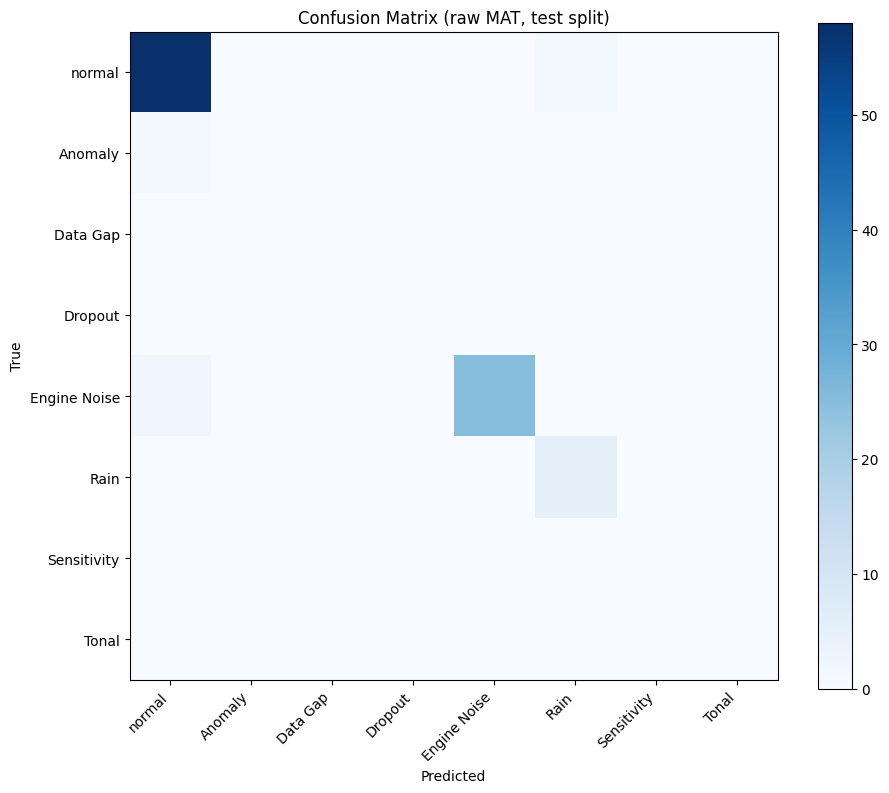

In [39]:
# Evaluate on test split using raw MAT spectrograms
from src.ssamba.dataset import get_onc_spectrogram_data
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix

# Build supervised datasets with consistent multiclass mapping (same ratios/seed as training)
ssl_tr, ssl_va, test_ds, tr_ds, va_ds = get_onc_spectrogram_data(
    data_path=DATA_H5,
    seed=getattr(args, 'split_seed', 42),
    train_ratio=getattr(args, 'train_ratio', 0.8),
    val_ratio=getattr(args, 'val_ratio', 0.1),
    target_length=getattr(args, 'target_length', 1024),
    num_mel_bins=getattr(args, 'num_mel_bins', 128),
    dataset_mean=getattr(args, 'dataset_mean', None),
    dataset_std=getattr(args, 'dataset_std', None),
    mixup=0.0,
    ood=getattr(args, 'ood', -1) if hasattr(args, 'ood') else -1,
    amount=1.0 if getattr(args, 'amount', None) is None else getattr(args, 'amount'),
    subsample_test=False,
    multiclass=True,
    num_classes=getattr(args, 'num_classes', 8)
)

# Get full H5 sources for name matching
with h5py.File(DATA_H5, 'r') as hf:
    all_sources = hf['sources'][:]

def _decode(x):
    return x.decode('utf-8') if isinstance(x, (bytes, np.bytes_)) else str(x)

# Collect test-set raw MAT paths and ground-truth labels (indices)
matched_mat_paths = []
y_true_idx = []
matched_h5_indices = []

print(f"Scanning {len(test_ds.sample_info)} test samples for raw MAT matches under MAT_ROOTS...")
for s in tqdm(test_ds.sample_info, desc='collect-test-mats'):
    h5_idx = int(s['index'])
    src_name = _decode(all_sources[h5_idx])
    mp = find_matching_mat_ci(src_name) if 'find_matching_mat_ci' in globals() else None
    if mp is None:
        continue
    matched_mat_paths.append(mp)
    matched_h5_indices.append(h5_idx)
    # Convert label strings to class index via dataset mapping
    y_true_idx.append(int(test_ds._get_multiclass_labels(s['labels']).item()))

print(f"Matched {len(matched_mat_paths)} / {len(test_ds.sample_info)} test samples to raw MAT files")

# Bail if nothing matched
if len(matched_mat_paths) == 0:
    raise RuntimeError('No test samples matched to MAT_ROOTS. Add the correct raw MAT folders to MAT_ROOTS.')

# Build and run inference over matched raw MAT files using H5-like tensor layout [C,F,T]
B = 32
batched_probs = []
paths = matched_mat_paths

with torch.no_grad():
    for i in tqdm(range(0, len(paths), B), desc='test-mat-inference'):
        batch = []
        for pth in paths[i:i+B]:
            arr = load_mat_spectrogram(pth, EXPECTED_SHAPE)
            # Use H5-like preprocessing: resize -> normalize -> [C,F,T]
            arr = resize_to_target(arr, TARGET_SIZE)
            arr = normalize_spectrogram(
                arr,
                dataset_mean=getattr(args, 'dataset_mean', None),
                dataset_std=getattr(args, 'dataset_std', None),
                amount=1.0 if getattr(args, 'amount', None) is None else getattr(args, 'amount'))
            ten = preprocess_to_tensor(arr)  # [1,F,T]
            batch.append(ten)
        if not batch:
            continue
        x = torch.stack(batch, dim=0).to(DEVICE)  # [B,1,F,T]
        logits = model(x, task=getattr(args, 'task', 'ft_cls'))
        probs = torch.softmax(logits, dim=1).cpu().numpy()
        batched_probs.append(probs)

prob_mat = np.concatenate(batched_probs, axis=0)

# Align model class order to test_ds class order before argmax
# model classes from earlier probe (class_names), eval classes from test_ds
model_class_names = class_names  # from earlier probe_ds
class_names_eval = [test_ds.index_to_label[i] for i in range(len(test_ds.index_to_label))]
name_to_model_idx = {name: i for i, name in enumerate(model_class_names)}

aligned_probs = np.zeros((prob_mat.shape[0], len(class_names_eval)), dtype=np.float32)
missing = []
for j, name in enumerate(class_names_eval):
    if name in name_to_model_idx:
        aligned_probs[:, j] = prob_mat[:, name_to_model_idx[name]]
    else:
        missing.append(name)
if missing:
    print('Warning: classes missing from model outputs (filled with zeros):', missing)

# Compute metrics using aligned argmax
y_true_np = np.array(y_true_idx, dtype=int)
y_pred_np = aligned_probs.argmax(axis=1).astype(int)

acc = float(accuracy_score(y_true_np, y_pred_np))
f1_macro = float(f1_score(y_true_np, y_pred_np, average='macro'))
f1_micro = float(f1_score(y_true_np, y_pred_np, average='micro'))
print(f"Matched eval samples: {len(y_true_np)}")
print('Class order (eval):', class_names_eval)
print('Class order (model):', model_class_names)
print(f"Accuracy: {acc:.4f} | F1-macro: {f1_macro:.4f} | F1-micro: {f1_micro:.4f}")

# Per-class report (restrict to classes present in y_true/y_pred)
present_labels = sorted(np.unique(np.concatenate([y_true_np, y_pred_np])))
present_names = [class_names_eval[i] for i in present_labels]
print('\nPer-class report (present classes only):')
print('Present classes:', present_names)
print(classification_report(
    y_true_np,
    y_pred_np,
    labels=present_labels,
    target_names=present_names,
    digits=4,
    zero_division=0,
))

# Confusion matrix over all classes (keeps fixed layout)
labels_full = list(range(len(class_names_eval)))
cm = confusion_matrix(y_true_np, y_pred_np, labels=labels_full)
plt.figure(figsize=(1.2*len(class_names_eval), 1.0*len(class_names_eval)))
plt.imshow(cm, cmap='Blues')
plt.title('Confusion Matrix (raw MAT, test split)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(range(len(class_names_eval)), class_names_eval, rotation=45, ha='right')
plt.yticks(range(len(class_names_eval)), class_names_eval)
plt.colorbar()
plt.tight_layout()
plt.show()


In [35]:
# Baseline: evaluate model on H5 test dataset directly, and compare vs MAT predictions on same subset
from torch.utils.data import DataLoader

# Build DataLoader over test_ds (H5-based pipeline)
h5_loader = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=4)

# Run inference on H5 test set
all_logits = []
all_true = []
with torch.no_grad():
    for batch in tqdm(h5_loader, desc='h5-test-inference'):
        data, labels, _ = batch
        data = data.to(DEVICE)
        logits = model(data, task=getattr(args, 'task', 'ft_cls'))
        all_logits.append(logits.cpu())
        all_true.append(labels.cpu())

h5_logits = torch.cat(all_logits, dim=0).numpy()
h5_probs = torch.softmax(torch.tensor(h5_logits), dim=1).numpy()
h5_pred = h5_probs.argmax(axis=1)
h5_true = torch.cat(all_true, dim=0).numpy().astype(int)

# Metrics on full H5 test set
print('\nH5 test set metrics (full):')
acc_h5 = float(accuracy_score(h5_true, h5_pred))
f1_macro_h5 = float(f1_score(h5_true, h5_pred, average='macro'))
f1_micro_h5 = float(f1_score(h5_true, h5_pred, average='micro'))
print(f"Accuracy: {acc_h5:.4f} | F1-macro: {f1_macro_h5:.4f} | F1-micro: {f1_micro_h5:.4f}")

# Compare on matched subset (indices that have raw MAT files)
if len(matched_h5_indices) > 0:
    subset_mask = np.zeros(len(test_ds.sample_info), dtype=bool)
    # Map test_ds order to original index
    order_to_h5_idx = np.array([s['index'] for s in test_ds.sample_info])
    h5_idx_set = set(matched_h5_indices)
    for i, h5_idx in enumerate(order_to_h5_idx):
        if h5_idx in h5_idx_set:
            subset_mask[i] = True

    h5_true_sub = h5_true[subset_mask]
    h5_pred_sub = h5_pred[subset_mask]

    print(f"\nH5 test metrics on matched subset: n={subset_mask.sum()}")
    print(f"Acc: {accuracy_score(h5_true_sub, h5_pred_sub):.4f} | F1-macro: {f1_score(h5_true_sub, h5_pred_sub, average='macro'):.4f} | F1-micro: {f1_score(h5_true_sub, h5_pred_sub, average='micro'):.4f}")

    # Agreement between H5 predictions and MAT predictions on same subset
    # Align MAT predictions order to test_ds order
    mat_pred_by_h5_idx = {}
    for i, h5_idx in enumerate(matched_h5_indices):
        mat_pred_by_h5_idx[h5_idx] = int(np.argmax(aligned_probs[i]))

    aligned_mat_preds = []
    aligned_h5_preds = []
    for i, h5_idx in enumerate(order_to_h5_idx):
        if h5_idx in h5_idx_set:
            aligned_h5_preds.append(int(h5_pred[i]))
            aligned_mat_preds.append(mat_pred_by_h5_idx[h5_idx])

    aligned_h5_preds = np.array(aligned_h5_preds, dtype=int)
    aligned_mat_preds = np.array(aligned_mat_preds, dtype=int)

    agree = float(np.mean(aligned_h5_preds == aligned_mat_preds))
    print(f"Prediction agreement (H5 vs MAT) on matched subset: {agree:.4f}")
else:
    print('No matched subset to compare against H5 predictions.')


h5-test-inference:   0%|          | 0/52 [00:00<?, ?it/s]


H5 test set metrics (full):
Accuracy: 0.9430 | F1-macro: 0.7522 | F1-micro: 0.9430

H5 test metrics on matched subset: n=92
Acc: 0.9565 | F1-macro: 0.7093 | F1-micro: 0.9565
Prediction agreement (H5 vs MAT) on matched subset: 0.0761


In [38]:
# Optional: compare two preprocessing orders on the matched subset
# - 'h5_like': resize -> normalize -> [C,F,T]
# - 'mat_like': normalize -> resize -> [1,T,F]

def eval_pipeline_on_paths(paths, y_true_idx, mode='h5_like', batch_size=32):
    probs_list = []
    with torch.no_grad():
        for i in tqdm(range(0, len(paths), batch_size), desc=f'{mode}-inference'):
            batch = []
            for pth in paths[i:i+batch_size]:
                arr = load_mat_spectrogram(pth, EXPECTED_SHAPE)
                if mode == 'h5_like':
                    arr = resize_to_target(arr, TARGET_SIZE)
                    arr = normalize_spectrogram(
                        arr,
                        dataset_mean=getattr(args, 'dataset_mean', None),
                        dataset_std=getattr(args, 'dataset_std', None),
                        amount=1.0 if getattr(args, 'amount', None) is None else getattr(args, 'amount'))
                    ten = preprocess_to_tensor(arr)  # [1,F,T]
                else:  # mat_like
                    arr = normalize_spectrogram(
                        arr,
                        dataset_mean=getattr(args, 'dataset_mean', None),
                        dataset_std=getattr(args, 'dataset_std', None),
                        amount=1.0 if getattr(args, 'amount', None) is None else getattr(args, 'amount'))
                    ten = preprocess_with_resize_ctf(arr, TARGET_SIZE)  # [1,T,F]
                batch.append(ten)
            if not batch:
                continue
            x = torch.stack(batch, dim=0).to(DEVICE)
            logits = model(x, task=getattr(args, 'task', 'ft_cls'))
            probs = torch.softmax(logits, dim=1).cpu().numpy()
            probs_list.append(probs)
    probs = np.concatenate(probs_list, axis=0)
    # align classes to test_ds order
    name_to_model_idx = {name: i for i, name in enumerate(class_names)}
    class_names_eval = [test_ds.index_to_label[i] for i in range(len(test_ds.index_to_label))]
    aligned = np.zeros((probs.shape[0], len(class_names_eval)), dtype=np.float32)
    for j, name in enumerate(class_names_eval):
        if name in name_to_model_idx:
            aligned[:, j] = probs[:, name_to_model_idx[name]]
    y_pred = aligned.argmax(axis=1)
    y_true = np.array(y_true_idx, dtype=int)
    return {
        'acc': float(accuracy_score(y_true, y_pred)),
        'f1_macro': float(f1_score(y_true, y_pred, average='macro')),
        'f1_micro': float(f1_score(y_true, y_pred, average='micro')),
    }

if len(matched_mat_paths) > 0:
    print('Comparing preprocessing modes on matched subset...')
    m1 = eval_pipeline_on_paths(matched_mat_paths, y_true_idx, mode='h5_like')
    m2 = eval_pipeline_on_paths(matched_mat_paths, y_true_idx, mode='mat_like')
    print('h5_like:', m1)
    print('mat_like:', m2)
else:
    print('No matched_mat_paths available to compare modes.')


Comparing preprocessing modes on matched subset...


h5_like-inference:   0%|          | 0/3 [00:00<?, ?it/s]

mat_like-inference:   0%|          | 0/3 [00:00<?, ?it/s]

h5_like: {'acc': 0.9565217391304348, 'f1_macro': 0.7093240093240093, 'f1_micro': 0.9565217391304348}
mat_like: {'acc': 0.07608695652173914, 'f1_macro': 0.05714285714285715, 'f1_micro': 0.07608695652173914}
